# Análise das bases de dados — Dengue SINAN

Inventário dos arquivos em `data/raw/`: tamanho em disco, número de linhas, colunas e visão geral para orientar limpeza e modelagem.

**Fonte:** [Arboviroses — Dengue (dados abertos MS)](https://dadosabertos.saude.gov.br/dataset/arboviroses-dengue)

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

_cwd = Path.cwd()
ROOT = _cwd.parent if (_cwd.parent / "data" / "raw").exists() else _cwd
RAW = ROOT / "data" / "raw"
GEO = RAW / "geo" / "ba_municipios.geojson"

print(f"Projeto: {ROOT}")
print(f"Dados brutos: {RAW}")

Projeto: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv
Dados brutos: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv/data/raw


In [3]:
def human_size(n_bytes: int) -> str:
    """Formata bytes em B, KB, MB ou GB."""
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if n_bytes < 1024 or unit == "TB":
            return f"{n_bytes:.2f} {unit}" if unit != "B" else f"{n_bytes} B"
        n_bytes /= 1024


def count_lines(path: Path) -> int:
    """Conta linhas do arquivo (inclui cabeçalho)."""
    with path.open("rb") as f:
        return sum(1 for _ in f)


def csv_profile(path: Path) -> dict:
    """Metadados de um CSV SINAN sem carregar o arquivo inteiro."""
    size = path.stat().st_size
    lines = count_lines(path)

    with path.open("r", encoding="utf-8", errors="replace") as f:
        header = f.readline().rstrip("\n\r")
    cols = header.split(",")

    ano = path.stem.replace("DENGBR", "")
    zip_path = path.with_suffix(path.suffix + ".zip")
    zip_size = zip_path.stat().st_size if zip_path.exists() else None

    return {
        "arquivo": path.name,
        "ano": int(ano),
        "linhas_total": lines,
        "registros": lines - 1,
        "colunas": len(cols),
        "tamanho_bytes": size,
        "tamanho": human_size(size),
        "zip_bytes": zip_size,
        "zip": human_size(zip_size) if zip_size else None,
        "tem_zip": zip_path.exists(),
    }


def scan_deng_csv(raw_dir: Path) -> pd.DataFrame:
    rows = [csv_profile(p) for p in sorted(raw_dir.glob("DENGBR*.csv"))]
    df = pd.DataFrame(rows).sort_values("ano").reset_index(drop=True)
    df["tamanho_gb"] = df["tamanho_bytes"] / (1024**3)
    return df

## 1. Arquivos DENGBR (notificações nacionais)

Varredura de todos os `DENGBR*.csv` descompactados. A contagem de linhas lê o arquivo byte a byte (não usa pandas), então funciona mesmo com o DENGBR24 (~1,7 GB).

In [4]:
df = scan_deng_csv(RAW)

display_cols = [
    "arquivo",
    "ano",
    "registros",
    "colunas",
    "tamanho",
    "zip",
    "tem_zip",
]
df[display_cols]

,arquivo,ano,registros,colunas,tamanho,zip,tem_zip
0,DENGBR16.csv,16,2298020,119,561.94 MB,62.50 MB,True
1,DENGBR17.csv,17,518483,119,132.45 MB,15.02 MB,True
2,DENGBR18.csv,18,478880,119,122.92 MB,14.16 MB,True
3,DENGBR19.csv,19,2261956,119,585.65 MB,71.66 MB,True
4,DENGBR20.csv,20,1495117,121,381.07 MB,42.56 MB,True
5,DENGBR21.csv,21,1024635,121,271.32 MB,28.24 MB,True
6,DENGBR22.csv,22,1405095,121,374.76 MB,39.93 MB,True
7,DENGBR23.csv,23,1645956,121,442.20 MB,37.67 MB,True
8,DENGBR24.csv,24,6564924,121,1.71 GB,178.59 MB,True
9,DENGBR25.csv,25,1644938,121,436.02 MB,39.75 MB,True


In [5]:
total_registros = df["registros"].sum()
total_csv_bytes = df["tamanho_bytes"].sum()
total_zip_bytes = df["zip_bytes"].dropna().sum()

resumo = pd.DataFrame(
    {
        "métrica": [
            "Arquivos CSV",
            "Registros (soma anual)",
            "Tamanho CSV (descompactado)",
            "Tamanho ZIP (compactado)",
            "Média bytes/registro",
        ],
        "valor": [
            len(df),
            f"{total_registros:,}".replace(",", "."),
            human_size(total_csv_bytes),
            human_size(int(total_zip_bytes)),
            human_size(int(total_csv_bytes / total_registros)),
        ],
    }
)
resumo

,métrica,valor
0,Arquivos CSV,11
1,Registros (soma anual),19.729.636
2,Tamanho CSV (descompactado),5.04 GB
3,Tamanho ZIP (compactado),539.16 MB
4,Média bytes/registro,274 B


## 2. Visualizações

Registros e tamanho em disco por ano de exportação.

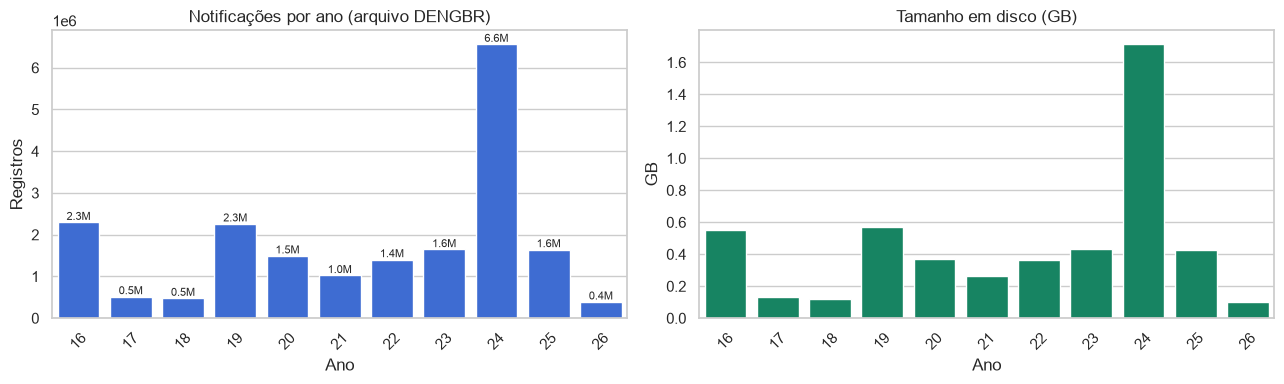

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=df, x="ano", y="registros", ax=axes[0], color="#2563eb")
axes[0].set_title("Notificações por ano (arquivo DENGBR)")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Registros")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(df["registros"]):
    axes[0].text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=8)

sns.barplot(data=df, x="ano", y="tamanho_gb", ax=axes[1], color="#059669")
axes[1].set_title("Tamanho em disco (GB)")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("GB")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3. Schema e amostra

Há **119 colunas** (2016–2019) e **121 colunas** (2020+). Delimitador: vírgula. A célula abaixo lê só as primeiras linhas do ano mais recente.

In [7]:
schema = df.groupby("colunas", as_index=False).agg(
    anos=("ano", lambda s: ", ".join(map(str, sorted(s)))),
    arquivos=("arquivo", ", ".join),
)
schema

,colunas,anos,arquivos
0,119,"16, 17, 18, 19","DENGBR16.csv, DENGBR17.csv, DENGBR18.csv, DENG..."
1,121,"20, 21, 22, 23, 24, 25, 26","DENGBR20.csv, DENGBR21.csv, DENGBR22.csv, DENG..."


In [8]:
amostra_path = RAW / f"DENGBR{df['ano'].max()}.csv"
amostra = pd.read_csv(amostra_path, nrows=5, low_memory=False)

print(f"Amostra: {amostra_path.name} — {amostra.shape[1]} colunas")
amostra.head()

Amostra: DENGBR26.csv — 121 colunas


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2026-05-15,202619,2026,32,320530,32002,11835,2026-05-03,...,0,0,0,0,0,0,2024-05-08,0,0,0
1,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,...,0,0,0,0,0,0,2025-11-08,0,0,0
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,...,0,0,0,0,0,0,2026-01-05,0,0,0
3,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,...,0,0,0,0,0,0,2026-01-05,0,0,0
4,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-01-04,...,0,0,0,0,0,0,2026-01-05,0,0,0


In [9]:
# Estimativa de memória se carregássemos tudo de uma vez (amostra de 10k linhas)
sample_mem = pd.read_csv(amostra_path, nrows=10_000, low_memory=False).memory_usage(deep=True).sum()
estimativa_gb = sample_mem / 10_000 * total_registros / (1024**3)

pd.DataFrame(
    {
        "métrica": ["Memória amostra (10k linhas)", "Estimativa RAM p/ todos os anos"],
        "valor": [human_size(int(sample_mem)), f"~{estimativa_gb:.1f} GB"],
    }
)

,métrica,valor
0,Memória amostra (10k linhas),14.44 MB
1,Estimativa RAM p/ todos os anos,~27.8 GB


## 4. GeoJSON — municípios da Bahia

Camada auxiliar para mapas (`data/raw/geo/ba_municipios.geojson`).

In [10]:
with GEO.open(encoding="utf-8") as f:
    geo = json.load(f)

props = geo["features"][0]["properties"]
geo_df = pd.DataFrame(
    {
        "métrica": [
            "Arquivo",
            "Tamanho",
            "Tipo",
            "Municípios (features)",
            "Propriedades (exemplo)",
        ],
        "valor": [
            GEO.name,
            human_size(GEO.stat().st_size),
            geo["type"],
            len(geo["features"]),
            ", ".join(sorted(props.keys())[:6]) + ", ...",
        ],
    }
)
geo_df

,métrica,valor
0,Arquivo,ba_municipios.geojson
1,Tamanho,853.50 KB
2,Tipo,FeatureCollection
3,Municípios (features),417
4,Propriedades (exemplo),"codarea, ..."


## 5. Recorte Bahia (prévia)

Contagem rápida de notificações com residência na BA (`SG_UF == 'BA'`) em amostras de 100k linhas por arquivo — só para ter ordem de grandeza antes da limpeza completa.

In [11]:
def amostra_ba(path: Path, nrows: int = 100_000) -> dict:
    chunk = pd.read_csv(path, nrows=nrows, usecols=["SG_UF"], low_memory=False)
    ba = (chunk["SG_UF"] == "BA").sum()
    return {
        "arquivo": path.name,
        "amostra": len(chunk),
        "BA na amostra": ba,
        "% BA": round(100 * ba / len(chunk), 1),
    }


ba_preview = pd.DataFrame(amostra_ba(RAW / row["arquivo"]) for _, row in df.iterrows())
ba_preview

,arquivo,amostra,BA na amostra,% BA
0,DENGBR16.csv,100000,0,0.0
1,DENGBR17.csv,100000,0,0.0
2,DENGBR18.csv,100000,0,0.0
3,DENGBR19.csv,100000,0,0.0
4,DENGBR20.csv,100000,0,0.0
5,DENGBR21.csv,100000,0,0.0
6,DENGBR22.csv,100000,0,0.0
7,DENGBR23.csv,100000,0,0.0
8,DENGBR24.csv,100000,0,0.0
9,DENGBR25.csv,100000,0,0.0


## 6. Observações

| Ponto | Detalhe |
| --- | --- |
| **Sobreposição temporal** | Cada `DENGBRxx.csv` é snapshot anual; somar registros de todos os anos **não** dá casos únicos. |
| **Pico 2024** | DENGBR24 concentra ~6,5M linhas e ~1,7 GB — maior arquivo da coleção. |
| **2026 parcial** | DENGBR26 cobre só parte do ano (dados até a exportação). |
| **Próximo passo** | Filtrar BA → `data/interim/`, agregar município × semana → `data/processed/`. |

> Dicionário completo de campos: `_tony-docs/dicionario-dengue.md`